A centroid (bottom=0.00, top=0.30): x=2.0730, y=0.1459
B centroid (bottom=0.00, top=1.00): x=4.2222, y=0.4444
A+B centroid (A:0-0.3, B:0-1): x=3.6418, y=0.3638
A centroid (bottom=0.00, top=0.10): x=2.0248, y=0.0496
A+B centroid (A:0-0.1, B:0-0): x=2.0248, y=0.0496
A centroid (bottom=0.00, top=1.73): x=2.3226, y=0.6453
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-1.73, B:0-2): x=3.3372, y=0.6561
B centroid (bottom=0.00, top=2.00): x=4.3333, y=0.6667
A+B centroid (A:0-0, B:0-2): x=4.3333, y=0.6667


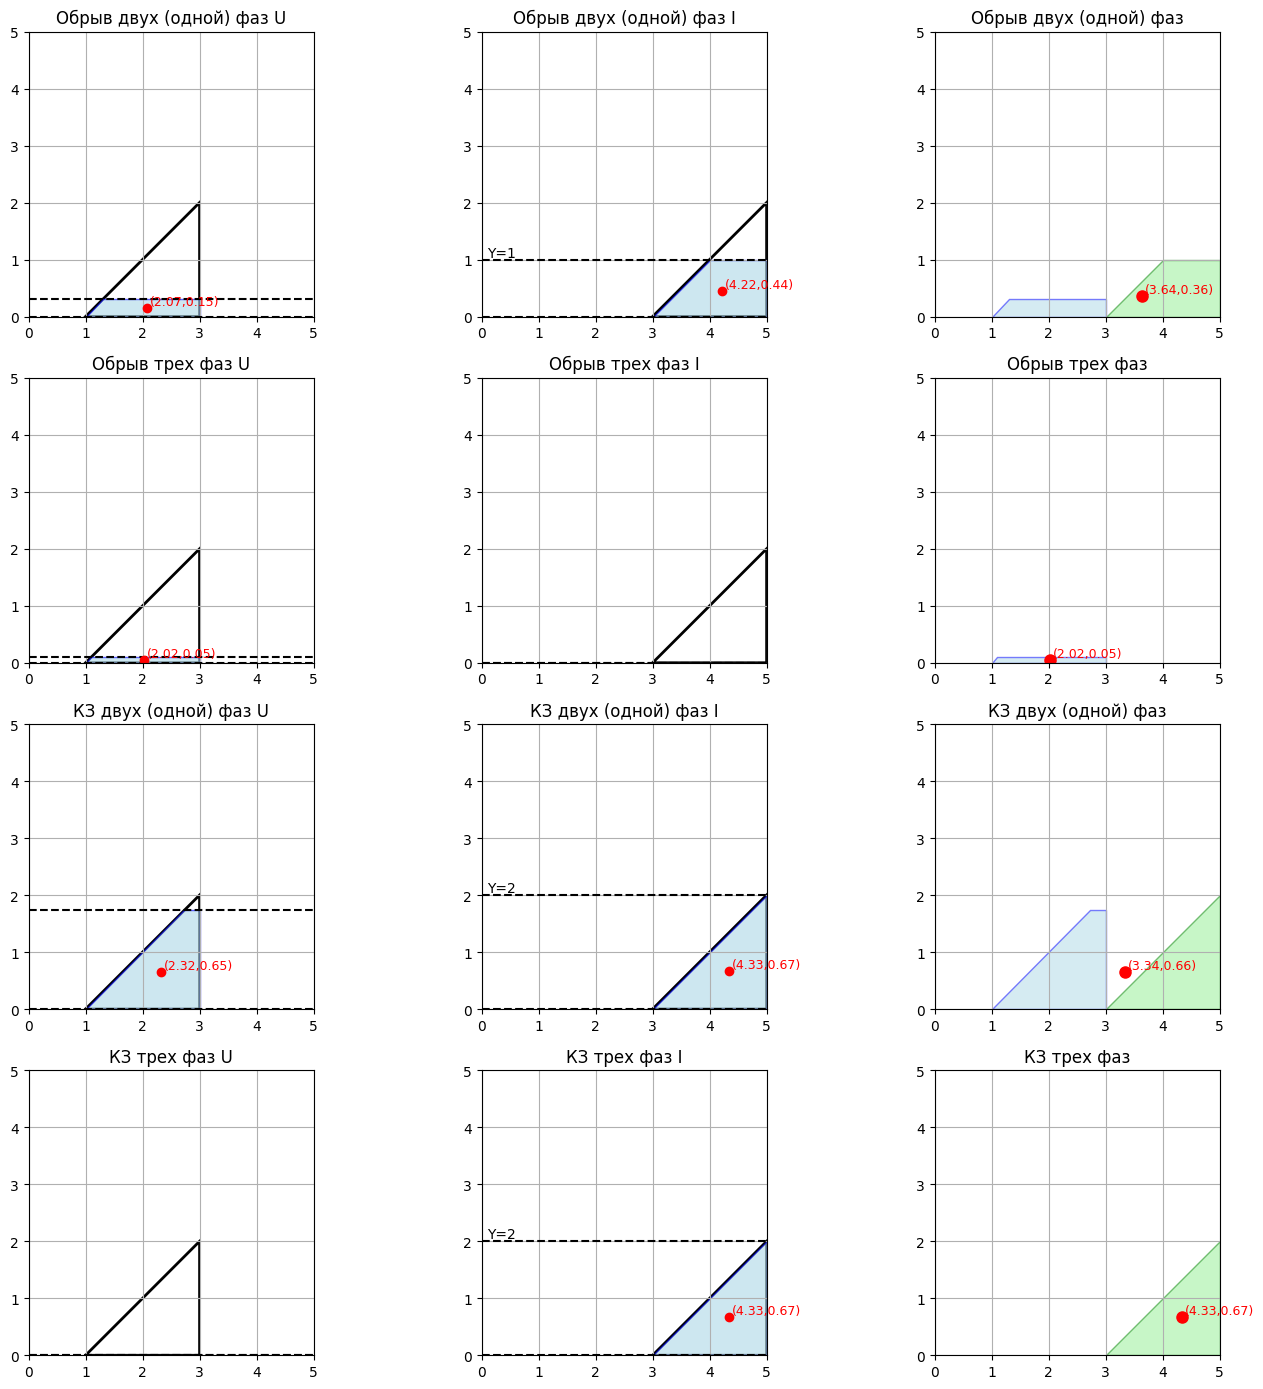

In [1]:
import matplotlib.pyplot as plt  # Библиотека для рисования графиков и фигур
from matplotlib.patches import Polygon  # Класс для рисования заливленных полигонов на графике
from shapely.geometry import Polygon as ShapelyPolygon  # "Умный" полигон для математических расчётов
from shapely.ops import unary_union  # Функция для объединения нескольких полигонов в один

# ==============================
# ТРЕУГОЛЬНИКИ - ОСНОВНЫЕ ФИГУРЫ
# ==============================
# triangleA и triangleB - координаты вершин двух треугольников
# Каждая точка = [X, Y]. Порядок: против часовой стрелки
# ИЗМЕНЕНИЕ: замените координаты на свои полигоны (квадраты, пятиугольники)
triangleA = [[1, 0], [3, 2], [3, 0]]  # Левый треугольник (напряжения U)
triangleB = [[3, 0], [5, 2], [5, 0]]  # Правый треугольник (токи I)

# ==============================
# ПАРАМЕТРЫ СРЕЗОВ ПО Y (горизонтальные полосы)
# ==============================
# bottom_cuts - нижняя граница среза (Y=0 = земля/пол)
# top_cuts - верхняя граница среза (разные высоты для 4 сценариев)
# ИЗМЕНЕНИЕ: добавьте больше сценариев или измените высоты
bottom_cuts_A = [0, 0, 0, 0]  # Всегда пол для треугольника A
top_cuts_A = [0.3, 0.1, 1.73, 0]  # 4 разных высоты среза для A

bottom_cuts_B = [0, 0, 0, 0]  # Всегда пол для треугольника B
top_cuts_B = [1, 0, 2, 2]  # 4 разных высоты среза для B


# ==============================
# ОСНОВНАЯ ФУНКЦИЯ: РЕЗКА ПОЛИГОНА ПО ГРИЗОНТАЛЬНОЙ ПОЛОСЕ
# ==============================
def slice_band(triangle, bottom, top):
    """
    Режет треугольник горизонтальной полосой Y∈[bottom, top]
    ВОЗВРАЩАЕТ: список точек нового полигона (срез)
    ИЗМЕНЕНИЕ: замените triangle на любой список точек многоугольника
    """
    intersections_bottom = []  # Список точек пересечения с НИЖНЕЙ линией Y=bottom
    intersections_top = []  # Список точек пересечения с ВЕРХНЕЙ линией Y=top
    inside = []  # Вершины, полностью внутри полосы

    # Перебираем все ребра треугольника (3 ребра)
    for i in range(3):  # i=0,1,2
        # Берём текущую вершину и следующую (циклически: 2→0)
        p1, p2 = triangle[i], triangle[(i + 1) % 3]

        # Если Y вершины в диапазоне полосы → сохраняем целиком
        if bottom <= p1[1] <= top:
            inside.append(p1)

        # ★★★ ПРОВЕРКА ПЕРЕСЕЧЕНИЯ С НИЖНЕЙ ЛИНИЕЙ ★★★
        # (p1[1]-bottom)*(p2[1]-bottom) < 0 = знаки разные = ребро пересекает линию
        if (p1[1] - bottom) * (p2[1] - bottom) < 0:
            # t = доля пути от p1 к p2, где Y=bottom (0≤t≤1)
            t = (bottom - p1[1]) / (p2[1] - p1[1])
            # Интерполируем X в точке пересечения
            x = p1[0] + t * (p2[0] - p1[0])
            intersections_bottom.append([x, bottom])

        # ★★★ ПРОВЕРКА ПЕРЕСЕЧЕНИЯ С ВЕРХНЕЙ ЛИНИЕЙ ★★★ (аналогично)
        if (p1[1] - top) * (p2[1] - top) < 0:
            t = (top - p1[1]) / (p2[1] - p1[1])
            x = p1[0] + t * (p2[0] - p1[0])
            intersections_top.append([x, top])

    # ★★★ СОБИРАЕМ КОНТУР НОВОГО ПОЛИГОНА ★★★
    # Нижняя линия: слева→справа по X
    bottom_line = sorted(intersections_bottom + [p for p in inside if p[1] == bottom],
                         key=lambda p: p[0])
    # Верхняя линия: справа→слева по X (важно для правильного замыкания!)
    top_line = sorted(intersections_top + [p for p in inside if p[1] == top],
                      key=lambda p: -p[0])
    # Средние точки (строго внутри полосы)
    middle_points = [p for p in inside if bottom < p[1] < top]

    # Конкатенируем: низ + середина + верх = полный контур
    band = bottom_line + middle_points + top_line

    # Удаляем дубликаты точек (если есть)
    band_unique = []
    for p in band:
        if p not in band_unique:
            band_unique.append(p)
    return band_unique  # Готовый полигон-срез!

# ======================
# РАСЧЁТ ЦЕНТРОИДА (центра масс) ОДНОГО ПОЛИГОНА
# ==============================
def centroid(points):
    """Вычисляет центр тяжести полигона с помощью Shapely"""
    if len(points) < 3:
        return None  # Недостаточно точек для полигона
    poly = ShapelyPolygon(points)  # Создаём Shapely-полигон
    if poly.is_valid:  # Проверяем, что полигон правильный (не самопересекается)
        return [poly.centroid.x, poly.centroid.y]  # Координаты центра
    return None


# ==============================
# ЦЕНТРОИД КОМБИНИРОВАННЫХ ПОЛИГОНОВ (A+B)
# ==============================
def combined_centroid(polys):
    """Объединяет несколько полигонов и находит их общий центроид"""
    shapes = []  # Список валидных Shapely-полигонов
    for p in polys:
        if len(p) >= 3:  # Минимум 3 точки
            poly = ShapelyPolygon(p)
            if poly.is_valid:
                shapes.append(poly)  # Добавляем только правильные

    if not shapes:
        return None  # Нет валидных полигонов

    comb = unary_union(shapes)  # СКЛЕИВАЕМ все полигоны в один
    return [comb.centroid.x, comb.centroid.y]  # Центр объединения


# ==============================
# ФУНКЦИЯ РИСОВАНИЯ ОДНОГО ТРЕУГОЛЬНИКА СО СРЕЗОМ
# ==============================
def draw_triangle(ax, triangle, bottom, top, name="A"):
    """Рисует треугольник, срез и центроид"""
    band = slice_band(triangle, bottom, top)  # Вычисляем срез

    # Исходный треугольник (чёрный контур)
    tri = Polygon(triangle, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(tri)  # Добавляем на график

    # Горизонтальные пунктирные линии среза
    ax.axhline(bottom, color='k', linestyle='--')  # Чёрный пунктир Y=bottom
    ax.axhline(top, color='k', linestyle='--')  # Чёрный пунктир Y=top

    # Подписи координат Y (только для целых значений 1,2)
    if bottom in [1, 2]:
        ax.text(0.1, bottom + 0.05, f"Y={bottom}", color='black', fontsize=10)
    if top in [1, 2]:
        ax.text(0.1, top + 0.05, f"Y={top}", color='black', fontsize=10)

    c = None  # Центроид
    if len(band) >= 3:  # Есть полигон для отрисовки
        # Рисуем срезанный полигон (синий)
        poly = Polygon(band, edgecolor='blue', facecolor='lightblue', alpha=0.6)
        ax.add_patch(poly)
        c = centroid(band)  # Вычисляем центр
        if c:
            # Красная точка + координаты
            ax.plot(c[0], c[1], 'ro', markersize=6)
            ax.text(c[0] + 0.05, c[1] + 0.05, f"({c[0]:.2f},{c[1]:.2f})",
                    color='red', fontsize=9)

    # Печатаем результат в консоль
    if c:
        print(f"{name} centroid (bottom={bottom:.2f}, top={top:.2f}): "
              f"x={c[0]:.4f}, y={c[1]:.4f}")
    return band  # Возвращаем срез для дальнейшего использования


# ==============================
# РИСОВАНИЕ КОМБИНИРОВАННОГО ГРАФИКА (A+B)
# ==============================
def draw_combined(ax, tA, tB, bA, tA_, bB, tB_):
    """Рисует срезы A (синий) + B (зелёный) + их общий центроид"""
    bandA = slice_band(tA, bA, tA_)  # Срез A
    bandB = slice_band(tB, bB, tB_)  # Срез B

    # Рисуем A синим
    if len(bandA) >= 3:
        ax.add_patch(Polygon(bandA, edgecolor='blue', facecolor='lightblue', alpha=0.5))

    # Рисуем B зелёным
    if len(bandB) >= 3:
        ax.add_patch(Polygon(bandB, edgecolor='green', facecolor='lightgreen', alpha=0.5))

    # Общий центроид A+B
    c = combined_centroid([bandA, bandB])
    if c:
        ax.plot(c[0], c[1], 'ro', markersize=8)  # Большая красная точка
        ax.text(c[0] + 0.05, c[1] + 0.05, f"({c[0]:.2f},{c[1]:.2f})",
                color='red', fontsize=9)
        print(f"A+B centroid (A:{bA}-{tA_}, B:{bB}-{tB_}): "
              f"x={c[0]:.4f}, y={c[1]:.4f}")


# ==============================
# ГЛАВНАЯ ФУНКЦИЯ - СОЗДАЁТ 12 ГРАФИКОВ
# ==============================
def main():
    """Создаёт таблицу 4x3 графиков для анализа 4 сценариев"""
    # Заголовки сценариев (электротехника: обрывы/КЗ фаз)
    # ИЗМЕНЕНИЕ: замените на свои названия экспериментов
    titles_A = ["Обрыв двух (одной) фаз U", "Обрыв трех фаз U",
                "КЗ двух (одной) фаз U", "КЗ трех фаз U"]
    titles_B = ["Обрыв двух (одной) фаз I", "Обрыв трех фаз I",
                "КЗ двух (одной) фаз I", "КЗ трех фаз I"]
    titles_AB = ["Обрыв двух (одной) фаз", "Обрыв трех фаз",
                 "КЗ двух (одной) фаз", "КЗ трех фаз"]

    # Создаём сетку 4 ряда × 3 столбца графиков
    fig, axes = plt.subplots(4, 3, figsize=(14, 14))

    # Перебираем 4 сценария (i=0,1,2,3)
    for i in range(4):
        # Получаем 3 графика текущего ряда: A | B | A+B
        axA, axB, axAB = axes[i]

        # Рисуем треугольник A с его срезом
        draw_triangle(axA, triangleA, bottom_cuts_A[i], top_cuts_A[i], name="A")
        # Рисуем треугольник B с его срезом
        draw_triangle(axB, triangleB, bottom_cuts_B[i], top_cuts_B[i], name="B")
        # Рисуем комбо A+B
        draw_combined(axAB, triangleA, triangleB,
                      bottom_cuts_A[i], top_cuts_A[i],
                      bottom_cuts_B[i], top_cuts_B[i])

        # Настройки осей для всех 3 графиков ряда
        for ax in [axA, axB, axAB]:
            ax.set_xlim(0, 5)  # Границы X: 0 до 5
            ax.set_ylim(0, 5)  # Границы Y: 0 до 5
            ax.set_aspect('equal')  # Квадратные пиксели (не вытягивать)
            ax.grid(True)  # Сетка

        # Заголовки столбцов
        axA.set_title(titles_A[i])
        axB.set_title(titles_B[i])
        axAB.set_title(titles_AB[i])

    # Финальная подгонка и показ
    plt.tight_layout()  # Убираем зазоры между графиками
    plt.show()  # ПОКАЗЫВАЕМ ВСЕ ГРАФИКИ


# Запуск программы
if __name__ == "__main__":
    main()  # Вызываем главную функцию